In [1]:
import numpy as np
import pandas as pd
import torch

from resnet_build import build_resnet_cifar


@torch.no_grad()
def exact_size_report(model, seed_bytes_per_layer=8):
    fp_total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())

    binary_total_bytes = 0
    ggm_param_names = set()

    for module_name, m in model.named_modules():
        if m.__class__.__name__ != "Conv2dGGM":
            continue

        g = m.groups
        k = m.kernel_size if isinstance(m.kernel_size, int) else m.kernel_size[0]
        cin_g = m.in_channels // g
        cout_g = m.out_channels // g
        K = cin_g * k * k

        W_flat = m.weight.reshape(g, cout_g, K).float()
        G = m.G.to(dtype=W_flat.dtype, device=W_flat.device)
        W_proj = torch.bmm(G, W_flat.transpose(1, 2))

        W_bits = (W_proj >= 0).transpose(1, 2).reshape(m.out_channels, m.N)
        W_bits = W_bits.to(torch.uint8).cpu().numpy()
        W_packed = np.packbits(W_bits, axis=1)
        Wb_bytes = int(W_packed.nbytes)

        scale_bytes = m.scale.numel() * m.scale.element_size()
        bias_bytes = 0 if m.bias is None else m.bias.numel() * m.bias.element_size()
        seed_bytes = seed_bytes_per_layer

        binary_total_bytes += Wb_bytes + scale_bytes + bias_bytes + seed_bytes

        ggm_param_names.add(f"{module_name}.weight")
        ggm_param_names.add(f"{module_name}.scale")
        if m.bias is not None:
            ggm_param_names.add(f"{module_name}.bias")

    for name, p in model.named_parameters():
        if name in ggm_param_names:
            continue
        binary_total_bytes += p.numel() * p.element_size()

    saved_mb = (fp_total_bytes - binary_total_bytes) / 1e6
    pct_smaller = 100.0 * (1.0 - binary_total_bytes / fp_total_bytes)

    return {
        "full_precision_bytes": fp_total_bytes,
        "binary_export_bytes": binary_total_bytes,
        "full_precision_MB": fp_total_bytes / 1e6,
        "binary_export_MB": binary_total_bytes / 1e6,
        "saved_MB": saved_mb,
        "pct_smaller": pct_smaller,
        "times_smaller": fp_total_bytes / binary_total_bytes,
    }


def readable_size_table(model_name="18", n_scales=range(1, 6), seed_bytes_per_layer=8):
    rows = []

    for n_scale in n_scales:
        model = build_resnet_cifar(
            model_name=model_name,
            num_classes=10,
            in_chans=3,
            use_ggm=True,
            N_scale=float(n_scale),
        )

        stats = exact_size_report(model, seed_bytes_per_layer=seed_bytes_per_layer)

        rows.append({
            "Model": f"ResNet-{model_name}",
            "N scale": int(n_scale),
            "Full precision size (MB)": round(stats["full_precision_MB"], 2),
            "Binary size (MB)": round(stats["binary_export_MB"], 2),
            "Space saved (MB)": round(stats["saved_MB"], 2),
            "Smaller by (%)": round(stats["pct_smaller"], 2),
            "Compression factor (x)": round(stats["times_smaller"], 2),
        })

    return pd.DataFrame(rows)


if __name__ == "__main__":
    df = readable_size_table(model_name="18", n_scales=range(1, 6))

    print("\nEasy-to-read model size table:\n")
    print(df.to_string(index=False))

    print("\nPlain-English summary:\n")
    for _, row in df.iterrows():
        print(
            f"N_scale = {row['N scale']}: "
            f"full precision = {row['Full precision size (MB)']} MB, "
            f"binary = {row['Binary size (MB)']} MB, "
            f"saved = {row['Space saved (MB)']} MB "
            f"({row['Smaller by (%)']}% smaller, "
            f"{row['Compression factor (x)']}x smaller)."
        )


Easy-to-read model size table:

    Model  N scale  Full precision size (MB)  Binary size (MB)  Space saved (MB)  Smaller by (%)  Compression factor (x)
ResNet-18        1                     44.71              1.48             43.24           96.69                   30.22
ResNet-18        2                     44.71              2.87             41.84           93.57                   15.56
ResNet-18        3                     44.71              4.27             40.45           90.45                   10.47
ResNet-18        4                     44.71              5.66             39.05           87.33                    7.90
ResNet-18        5                     44.71              7.06             37.66           84.21                    6.34

Plain-English summary:

N_scale = 1: full precision = 44.71 MB, binary = 1.48 MB, saved = 43.24 MB (96.69% smaller, 30.22x smaller).
N_scale = 2: full precision = 44.71 MB, binary = 2.87 MB, saved = 41.84 MB (93.57% smaller, 15.56x smaller)

In [2]:
import numpy as np
import pandas as pd
import torch

from resnet_build import build_resnet_cifar


@torch.no_grad()
def exact_size_report(model, seed_bytes_per_layer=8):
    fp_total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())

    binary_total_bytes = 0
    ggm_param_names = set()

    for module_name, m in model.named_modules():
        if m.__class__.__name__ != "Conv2dGGM":
            continue

        g = m.groups
        k = m.kernel_size if isinstance(m.kernel_size, int) else m.kernel_size[0]
        cin_g = m.in_channels // g
        cout_g = m.out_channels // g
        K = cin_g * k * k

        W_flat = m.weight.reshape(g, cout_g, K).float()
        G = m.G.to(dtype=W_flat.dtype, device=W_flat.device)
        W_proj = torch.bmm(G, W_flat.transpose(1, 2))

        W_bits = (W_proj >= 0).transpose(1, 2).reshape(m.out_channels, m.N)
        W_bits = W_bits.to(torch.uint8).cpu().numpy()
        W_packed = np.packbits(W_bits, axis=1)
        Wb_bytes = int(W_packed.nbytes)

        scale_bytes = m.scale.numel() * m.scale.element_size()
        bias_bytes = 0 if m.bias is None else m.bias.numel() * m.bias.element_size()
        seed_bytes = seed_bytes_per_layer

        binary_total_bytes += Wb_bytes + scale_bytes + bias_bytes + seed_bytes

        ggm_param_names.add(f"{module_name}.weight")
        ggm_param_names.add(f"{module_name}.scale")
        if m.bias is not None:
            ggm_param_names.add(f"{module_name}.bias")

    for name, p in model.named_parameters():
        if name in ggm_param_names:
            continue
        binary_total_bytes += p.numel() * p.element_size()

    saved_mb = (fp_total_bytes - binary_total_bytes) / 1e6
    pct_smaller = 100.0 * (1.0 - binary_total_bytes / fp_total_bytes)

    return {
        "full_precision_bytes": fp_total_bytes,
        "binary_export_bytes": binary_total_bytes,
        "full_precision_MB": fp_total_bytes / 1e6,
        "binary_export_MB": binary_total_bytes / 1e6,
        "saved_MB": saved_mb,
        "pct_smaller": pct_smaller,
        "times_smaller": fp_total_bytes / binary_total_bytes,
    }


def readable_size_table(model_name="18", n_scales=range(1, 6), seed_bytes_per_layer=8):
    rows = []

    for n_scale in n_scales:
        model = build_resnet_cifar(
            model_name=model_name,
            num_classes=10,
            in_chans=3,
            use_ggm=True,
            N_scale=float(n_scale),
        )

        stats = exact_size_report(model, seed_bytes_per_layer=seed_bytes_per_layer)

        rows.append({
            "Model": f"ResNet-{model_name}",
            "N scale": int(n_scale),
            "Full precision size (MB)": round(stats["full_precision_MB"], 2),
            "Binary size (MB)": round(stats["binary_export_MB"], 2),
            "Space saved (MB)": round(stats["saved_MB"], 2),
            "Smaller by (%)": round(stats["pct_smaller"], 2),
            "Compression factor (x)": round(stats["times_smaller"], 2),
        })

    return pd.DataFrame(rows)


if __name__ == "__main__":
    df = readable_size_table(model_name="20", n_scales=range(1, 6))

    print("\nEasy-to-read model size table:\n")
    print(df.to_string(index=False))

    print("\nPlain-English summary:\n")
    for _, row in df.iterrows():
        print(
            f"N_scale = {row['N scale']}: "
            f"full precision = {row['Full precision size (MB)']} MB, "
            f"binary = {row['Binary size (MB)']} MB, "
            f"saved = {row['Space saved (MB)']} MB "
            f"({row['Smaller by (%)']}% smaller, "
            f"{row['Compression factor (x)']}x smaller)."
        )


Easy-to-read model size table:

    Model  N scale  Full precision size (MB)  Binary size (MB)  Space saved (MB)  Smaller by (%)  Compression factor (x)
ResNet-20        1                      1.09              0.05              1.05           95.65                   22.98
ResNet-20        2                      1.09              0.08              1.01           92.56                   13.45
ResNet-20        3                      1.09              0.12              0.98           89.48                    9.50
ResNet-20        4                      1.09              0.15              0.94           86.39                    7.35
ResNet-20        5                      1.09              0.18              0.91           83.30                    5.99

Plain-English summary:

N_scale = 1: full precision = 1.09 MB, binary = 0.05 MB, saved = 1.05 MB (95.65% smaller, 22.98x smaller).
N_scale = 2: full precision = 1.09 MB, binary = 0.08 MB, saved = 1.01 MB (92.56% smaller, 13.45x smaller).
N_

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# -----------------------------
# Data
# -----------------------------
r20_labels = np.array(["FP", "s=1", "s=2", "s=3", "s=4", "s=5"])
r20_memory = np.array([1.09, 0.05, 0.08, 0.12, 0.15, 0.18])
r20_acc = np.array([92.10, 88.04, 89.36, 90.04, 90.45, 90.67])

r18_labels = np.array(["FP", "s=1", "s=2", "s=3", "s=4", "s=5"])
r18_memory = np.array([44.71, 1.48, 2.87, 4.27, 5.66, 7.06])
r18_acc = np.array([94.80, 93.55, 94.20, 94.65, 94.77, 94.76])



# -----------------------------
# Styling for paper
# -----------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def setup_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.20)
    ax.tick_params(direction="out", length=3.5, width=0.8)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(plt.NullFormatter())

def annotate_points(ax, xs, ys, labels, offsets, fontsize=9):
    for x, y, lab in zip(xs, ys, labels):
        dx, dy = offsets[lab]
        ax.annotate(
            lab,
            (x, y),
            textcoords="offset points",
            xytext=(dx, dy),
            ha="center" if dx == 0 else ("left" if dx > 0 else "right"),
            va="bottom" if dy > 0 else "top",
            fontsize=fontsize,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.85
            )
        )

def plot_panel(ax, memory, acc, labels, title, xticks, xlim, ylim, offsets_q, offset_fp):
    fp_idx = np.where(labels == "FP")[0][0]
    n_idx = np.where(labels != "FP")[0]

    # Sort quantized points by memory for a smooth tradeoff curve
    order = np.argsort(memory[n_idx])
    mem_q = memory[n_idx][order]
    acc_q = acc[n_idx][order]
    lab_q = labels[n_idx][order]

    sizes_q = 30 + 120 * (mem_q / mem_q.max()) 

    setup_axis(ax)

    # Quantized curve
    ax.plot(
        mem_q, acc_q,
        linewidth=1.8,
        marker="o",
        markersize=6,
        label="GGM with N-scale s",
        zorder=2
    )

    # FP point highlighted
    ax.scatter(
        memory[fp_idx], acc[fp_idx],
        s=52,
        marker="D",
        edgecolors="black",
        linewidths=0.8,
        label="FP",
        zorder=3
    )

    # Annotate quantized points
    annotate_points(ax, mem_q, acc_q, lab_q, offsets_q, fontsize=9)

    # Annotate FP
    ax.annotate(
        "FP",
        (memory[fp_idx], acc[fp_idx]),
        textcoords="offset points",
        xytext=offset_fp,
        ha="left" if offset_fp[0] > 0 else "right",
        va="bottom" if offset_fp[1] > 0 else "top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

    ax.set_title(title, pad=6)
    # ax.set_xlabel("Memory (MB)")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks(xticks)

# -----------------------------
# Manually tuned offsets
# -----------------------------
r20_offsets = {
    "s=1": (10, 0),
    "s=2": (5, -5),
    "s=3": (5, -5),
    "s=4": (5, -5),
    "s=5": (5, 5),
}
r20_fp_offset = (-10, 8)

r18_offsets = {
    "s=1": (10, 0),
    "s=2": (5, -5),
    "s=3": (5, -5),
    "s=4": (0, 5),
    "s=5": (5, 5),   # shifted right to avoid overlap
}
r18_fp_offset = (-10, 8)

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6), dpi=300, constrained_layout=True)

plot_panel(
    axes[0],
    r20_memory, r20_acc, r20_labels,
    "(a) ResNet-20",
    xticks=[0.05, 0.1, 0.2, 0.5, 1.0],
    xlim=(0.045, 1.3),
    ylim=(87.8, 92.4),
    offsets_q=r20_offsets,
    offset_fp=r20_fp_offset
)

plot_panel(
    axes[1],
    r18_memory, r18_acc, r18_labels,
    "(b) ResNet-18",
    xticks=[1, 2, 5, 10, 20, 50],
    xlim=(1.2, 50),
    ylim=(93.45, 94.95),
    offsets_q=r18_offsets,
    offset_fp=r18_fp_offset
)

axes[0].set_ylabel("Accuracy (%)")
# axes[1].set_ylabel("Accuracy (%)")
axes[0].set_xlabel("Memory (MB)")

# Shared legend
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels_legend,
    loc="lower right",
    ncol=1,                 # one column => two rows for 2 entries
    frameon=False,
    bbox_to_anchor=(0.98, 0.22)
)

plt.savefig("accuracy_memory_tradeoff.pdf", bbox_inches="tight")
plt.savefig("accuracy_memory_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
import matplotlib.pyplot as plt
import numpy as np

r20_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r20_memory = np.array([1.09, 0.05, 0.08, 0.12, 0.15, 0.18])
r20_acc = np.array([92.10, 88.04, 89.36, 90.04, 90.45, 90.67])

r18_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r18_memory = np.array([44.71, 1.48, 2.87, 4.27, 5.66, 7.06])
r18_acc = np.array([94.80, 93.55, 94.20, 94.65, 94.77, 94.76])

# Bubble sizes proportional to memory
r20_sizes = r20_memory * 600
r18_sizes = r18_memory * 50

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, mem, acc, labels, sizes, title in [
    (axes[0], r20_memory, r20_acc, r20_labels, r20_sizes, "ResNet-20"),
    (axes[1], r18_memory, r18_acc, r18_labels, r18_sizes, "ResNet-18"),
]:
    ax.scatter(mem, acc, s=sizes, alpha=0.6, edgecolors="black", linewidths=0.8)

    for x, y, label in zip(mem, acc, labels):
        ax.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(0, -14),
            ha="center",
            va="top",
            fontsize=9,
            fontweight="normal",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
        )

    ax.set_xlabel("Memory (MB)", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)

# Separate linear x ranges
axes[0].set_xlim(0, 1.15)
axes[1].set_xlim(0, 47)

# Optional nicer ticks
axes[0].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1].set_xticks([0, 10, 20, 30, 40])

axes[0].set_ylim(87.7, 92.5)
axes[1].set_ylim(93.3, 95.0)

plt.tight_layout()
plt.show()

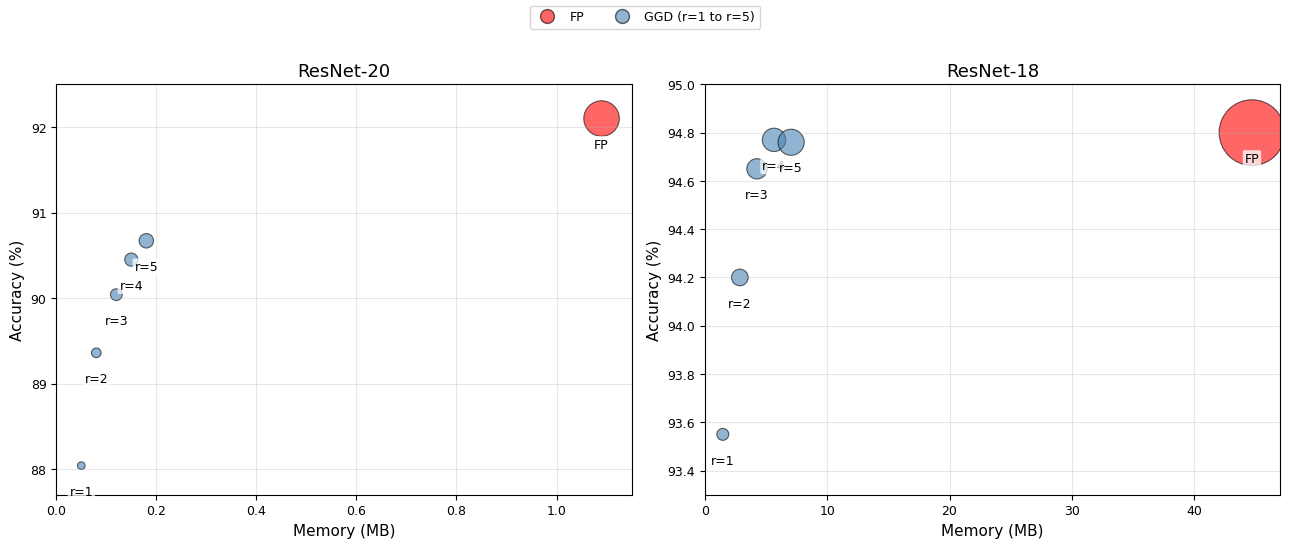

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

r20_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r20_memory = np.array([1.09, 0.05, 0.08, 0.12, 0.15, 0.18])
r20_acc = np.array([92.10, 88.04, 89.36, 90.04, 90.45, 90.67])

r18_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r18_memory = np.array([44.71, 1.48, 2.87, 4.27, 5.66, 7.06])
r18_acc = np.array([94.80, 93.55, 94.20, 94.65, 94.77, 94.76])

# Bubble sizes proportional to memory
r20_sizes = r20_memory * 600
r18_sizes = r18_memory * 50

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

fp_color = "red"
rank_color = "steelblue"

for ax, mem, acc, labels, sizes, title in [
    (axes[0], r20_memory, r20_acc, r20_labels, r20_sizes, "ResNet-20"),
    (axes[1], r18_memory, r18_acc, r18_labels, r18_sizes, "ResNet-18"),
]:
    # Assign colors: FP one color, others another
    colors = [fp_color if label == "FP" else rank_color for label in labels]

    ax.scatter(mem, acc, s=sizes, c=colors, alpha=0.6, edgecolors="black", linewidths=0.8)

    for x, y, label in zip(mem, acc, labels):
        ax.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(0, -14),
            ha="center",
            va="top",
            fontsize=9,
            fontweight="normal",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
        )

    ax.set_xlabel("Memory (MB)", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)

# Separate linear x ranges
axes[0].set_xlim(0, 1.15)
axes[1].set_xlim(0, 47)

# Optional nicer ticks
axes[0].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1].set_xticks([0, 10, 20, 30, 40])

axes[0].set_ylim(87.7, 92.5)
axes[1].set_ylim(93.3, 95.0)

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='FP',
           markerfacecolor=fp_color, markeredgecolor='black', markersize=10, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='GGM (r=1 to r=5)',
           markerfacecolor=rank_color, markeredgecolor='black', markersize=10, alpha=0.6),
]

fig.legend(handles=legend_elements, loc='upper center', ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

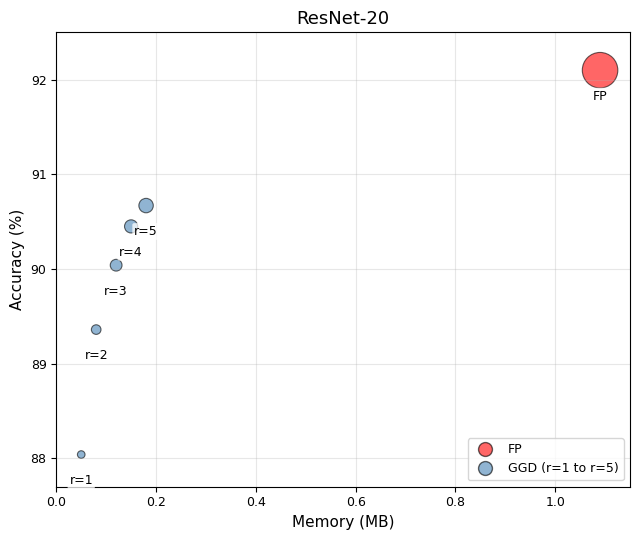

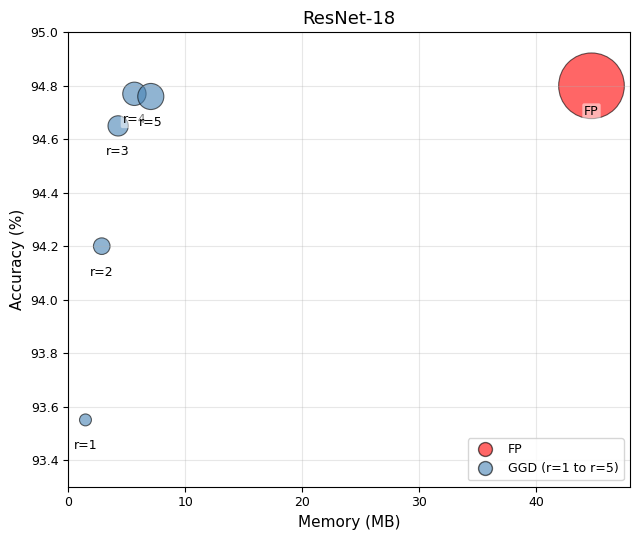

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

r20_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r20_memory = np.array([1.09, 0.05, 0.08, 0.12, 0.15, 0.18])
r20_acc = np.array([92.10, 88.04, 89.36, 90.04, 90.45, 90.67])

r18_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r18_memory = np.array([44.71, 1.48, 2.87, 4.27, 5.66, 7.06])
r18_acc = np.array([94.80, 93.55, 94.20, 94.65, 94.77, 94.76])

# Bubble sizes proportional to memory
r20_sizes = r20_memory * 600
r18_sizes = r18_memory * 50

fp_color = "red"
rank_color = "steelblue"

# Common legend entries
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='FP',
           markerfacecolor=fp_color, markeredgecolor='black',
           markersize=10, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='GGM (r=1 to r=5)',
           markerfacecolor=rank_color, markeredgecolor='black',
           markersize=10, alpha=0.6),
]

# -------- ResNet-20 --------
fig, ax = plt.subplots(figsize=(6.5, 5.5))

colors = [fp_color if label == "FP" else rank_color for label in r20_labels]
ax.scatter(r20_memory, r20_acc, s=r20_sizes, c=colors, alpha=0.6,
           edgecolors="black", linewidths=0.8)

for x, y, label in zip(r20_memory, r20_acc, r20_labels):
    ax.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(0, -14),
        ha="center",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
    )

ax.set_xlabel("Memory (MB)", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_title("ResNet-20", fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.15)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(87.7, 92.5)
ax.legend(handles=legend_elements, loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

# -------- ResNet-18 --------
fig, ax = plt.subplots(figsize=(6.5, 5.5))

colors = [fp_color if label == "FP" else rank_color for label in r18_labels]
ax.scatter(r18_memory, r18_acc, s=r18_sizes, c=colors, alpha=0.6,
           edgecolors="black", linewidths=0.8)

for x, y, label in zip(r18_memory, r18_acc, r18_labels):
    ax.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(0, -14),
        ha="center",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.5),
    )

ax.set_xlabel("Memory (MB)", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_title("ResNet-18", fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 48)
ax.set_xticks([0, 10, 20, 30, 40])
ax.set_ylim(93.3, 95.0)
ax.legend(handles=legend_elements, loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

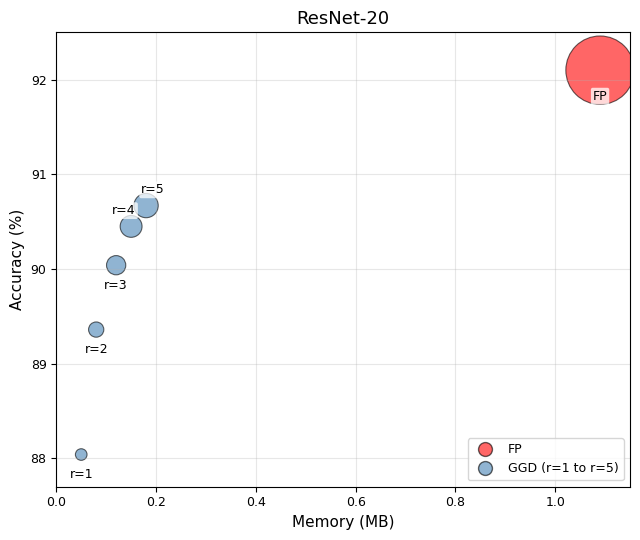

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# -----------------------------
# Data
# -----------------------------
r20_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r20_memory = np.array([1.09, 0.05, 0.08, 0.12, 0.15, 0.18])
r20_acc = np.array([92.10, 88.04, 89.36, 90.04, 90.45, 90.67])

r18_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r18_memory = np.array([44.71, 1.48, 2.87, 4.27, 5.66, 7.06])
r18_acc = np.array([94.80, 93.55, 94.20, 94.65, 94.77, 94.76])

# Bubble sizes proportional to memory
# r20_sizes = r20_memory * 600
# r18_sizes = r18_memory * 50

size_scale = 2200
size_power = 1.15   # >1 exaggerates large models

r20_sizes = (r20_memory ** size_power) * size_scale
r18_sizes = (r18_memory ** size_power) * size_scale

fp_color = "red"
rank_color = "steelblue"

# -----------------------------
# Custom label offsets
# Format: (x_offset, y_offset)
# -----------------------------
r20_offsets = {
    "FP": (0, -14),
    "r=1": (0, -10),
    "r=2": (0, -10),
    "r=3": (0, -10),
    "r=4": (-5, 16),
    "r=5": (5, 16),
}

r18_offsets = {
    "FP": (0, -25),
    "r=1": (0, -10),
    "r=2": (0, -16),
    "r=3": (0, -10),
    "r=4": (-8, 20),
    "r=5": (8, 20),
}

# -----------------------------
# Common legend entries
# -----------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='FP',
           markerfacecolor=fp_color, markeredgecolor='black',
           markersize=10, alpha=0.6),
    Line2D([0], [0], marker='o', color='w', label='GGM (r=1 to r=5)',
           markerfacecolor=rank_color, markeredgecolor='black',
           markersize=10, alpha=0.6),
]

# -----------------------------
# ResNet-20
# -----------------------------
fig, ax = plt.subplots(figsize=(6.5, 5.5))

colors = [fp_color if label == "FP" else rank_color for label in r20_labels]
ax.scatter(
    r20_memory,
    r20_acc,
    s=r20_sizes,
    c=colors,
    alpha=0.6,
    edgecolors="black",
    linewidths=0.8
)

for x, y, label in zip(r20_memory, r20_acc, r20_labels):
    dx, dy = r20_offsets[label]
    ax.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(dx, dy),
        ha="center",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
    )

ax.set_xlabel("Memory (MB)", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_title("ResNet-20", fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.15)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(87.7, 92.5)
ax.legend(handles=legend_elements, loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

# -----------------------------
# ResNet-18
# -----------------------------
fig, ax = plt.subplots(figsize=(6.5, 5.5))

colors = [fp_color if label == "FP" else rank_color for label in r18_labels]
ax.scatter(
    r18_memory,
    r18_acc,
    s=r18_sizes,
    c=colors,
    alpha=0.6,
    edgecolors="black",
    linewidths=0.8
)

for x, y, label in zip(r18_memory, r18_acc, r18_labels):
    dx, dy = r18_offsets[label]
    ax.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(dx, dy),
        ha="center",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.5),
    )

ax.set_xlabel("Memory (MB)", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_title("ResNet-18", fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 48)
ax.set_xticks([0, 10, 20, 30, 40])
ax.set_ylim(93.3, 95.0)
ax.legend(handles=legend_elements, loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data
# -----------------------------
r20_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r20_memory = np.array([1.09, 0.05, 0.08, 0.12, 0.15, 0.18])
r20_acc = np.array([92.10, 88.04, 89.36, 90.04, 90.45, 90.67])

r18_labels = ["FP", "r=1", "r=2", "r=3", "r=4", "r=5"]
r18_memory = np.array([44.71, 1.48, 2.87, 4.27, 5.66, 7.06])
r18_acc = np.array([94.80, 93.55, 94.20, 94.65, 94.77, 94.76])

def plot_memory_bars(labels, memory, acc, title):
    fig, ax = plt.subplots(figsize=(7, 5.5))

    y = np.arange(len(labels))
    colors = ["red" if label == "FP" else "steelblue" for label in labels]

    bars = ax.barh(y, memory, color=colors, edgecolor="black", alpha=0.8)
    ax.invert_yaxis()

    xmax = memory.max()
    outside_offset = xmax * 0.02

    for bar, m, a in zip(bars, memory, acc):
        y_text = bar.get_y() + bar.get_height() / 2
        ax.text(
            m + outside_offset,
            y_text,
            f"{a:.2f}%",
            va="center",
            ha="left",
            fontsize=10,
            color="black"
        )

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Memory (MB)", fontsize=11)
    ax.set_ylabel("Configuration", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.grid(axis="x", alpha=0.3)

    # Give enough space for labels on the right
    ax.set_xlim(0, xmax * 1.22)

    plt.tight_layout()
    plt.show()

plot_memory_bars(r20_labels, r20_memory, r20_acc, "ResNet-20")
plot_memory_bars(r18_labels, r18_memory, r18_acc, "ResNet-18")